In [23]:
%matplotlib inline
from nansat import Nansat
import numpy as np
from openwind.wind_data import fetch_era5_data, preprocess_wind_data
from datetime import timedelta
import matplotlib.pyplot as plt
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

In [24]:
# Step 1: Define search parameters (time and coordinates) to find ERA5 field
# In case of collocation with Sentinel-1 data these parameters can be extracted from the 
# Sentinel-1 product metadata.

# Read a Sentinel-1 L1 GRD product using Nansat
s1_frame = Nansat('/src/.devcontainer/S1A_IW_GRDH_1SDV_20220110T173429_20220110T173454_041401_04EC3B_31E4.SAFE')
# In order to speed up the processing we will resample the Sentinel-1 product to a pixel size of about 200 m
s1_frame.resize(0.1, resample_alg=1)

0.1

In [25]:
s1_lons, s1_lats = s1_frame.get_geolocation_grids()
central_lon = np.nanmean(s1_lons)
central_lat = np.nanmean(s1_lats)

In [26]:
s1_time = s1_frame.time_coverage_start
s1_time = s1_time if s1_time.minute <= 30 else s1_time + timedelta(hours=1)

In [27]:
# Find and download ERA5 data
# Artem 6 Mar 2024 - Data request takes very long time due to new CDS system migration 
# era5_uri = fetch_era5_data(s1_time, central_lat, central_lon, '/src/.devcontainer/')

In [28]:
# Derive wind speed and direction from the model
era5_uri = 'ERA5_20220110T1800.nc'
wind_spd, wind_dir = preprocess_wind_data(era5_uri, dst_geometry=s1_frame)

>> Reading ERA5_20220110T1800.nc


Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.1 degrees threshold.
Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.1 degrees threshold.
Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.1 degrees threshold.
/opt/conda/lib/python3.11/site-packages/nansat-1.6.0-py3.11-linux-x86_64.egg/nansat/mappers/mapper_netcdf_cf.py:393: UserWarning: GDAL cannot determine the dataset projection - using Nansat spatial reference WKT, assuming a regular longitude/latitude grid
  warnings.warn('GDAL cannot determine the dataset projection - using Nansat ' \
Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.1 degrees threshold.
Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.1 degrees threshold.
Warning 1: Latitude grid not spaced evenly.  Setting projection for grid spacing is within 0.

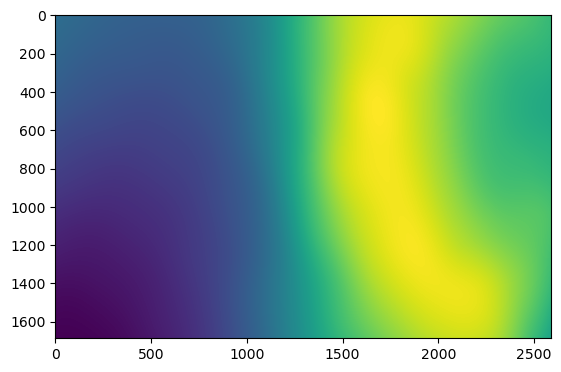

In [29]:
%matplotlib inline
plt.imshow(wind_dir)

In [31]:
import xarray as xr
import pythesint as pti
d = xr.open_dataset('/src/tutorial/S1A_IW_GRDH_1SDV_20220110T173429_20220110T173454_041401_04EC3B_31E4.nc')

In [32]:
wind_spd_meta = pti.get_cf_standard_name('wind_speed')
wind_spd_meta['source'] = 'ERA5'
wind_spd_meta['_FillValue'] = -999.

wind_dir_meta = pti.get_cf_standard_name('wind_from_direction')
wind_dir_meta['source'] = 'ERA5'
wind_dir_meta['_FillValue'] = -999.


d['wind_spd'] = xr.Variable(('row', 'col'), wind_spd, wind_spd_meta)
d['wind_dir'] = xr.Variable(('row', 'col'), wind_dir, wind_dir_meta)

ValueError: conflicting sizes for dimension 'row': length 1687 on 'wind_spd' and length 1698 on {'row': 'sigma0_s1dn', 'col': 'sigma0_s1dn'}

In [21]:
d

<xarray.Dataset> Size: 210MB
Dimensions:             (row: 1687, col: 2590)
Coordinates:
    lat                 (row, col) float64 35MB ...
    lon                 (row, col) float64 35MB ...
Dimensions without coordinates: row, col
Data variables:
    sigma0_s1dn         (row, col) float32 17MB ...
    sigma0              (row, col) float32 17MB ...
    angle_of_incidence  (row, col) float64 35MB ...
    look_direction      (row, col) float32 17MB ...
    watermask           (row, col) float32 17MB ...
    wind_spd            (row, col) float32 17MB 5.713 5.711 5.71 ... 2.577 2.575
    wind_dir            (row, col) float32 17MB 271.9 271.9 ... 290.7 290.6
Attributes:
    data_center:          {"Bucket_Level0": "MULTINATIONAL ORGANIZATIONS", "B...
    entry_id:             S1A_IW_GRDH_1SDV_20220110T173429_20220110T173454_04...
    entry_title:          SENTINEL-1A SAR
    filename:             /vsimem/U4TWXTJXHY.vrt
    instrument:           {"Category": "Earth Remote Sensing Instruments", "C...
    iso_topic_category:   {"iso_topic_category": "Oceans"}
    platform:             {"Basis": "Space-based Platforms", "Category": "Ear...
    summary:              SENTINEL-1A SAR data
    time_coverage_end:    2022-01-10T17:34:54.365408
    time_coverage_start:  2022-01-10T17:34:29.367288

In [22]:
d.to_netcdf('test.nc')

OrderedDict([('standard_name', 'wind_speed'),
             ('canonical_units', 'm s-1'),
             ('definition',
              'Speed is the magnitude of velocity. Wind is defined as a two-dimensional (horizontal) air velocity vector, with no vertical component. (Vertical motion in the atmosphere has the standard name upward_air_velocity.) The wind speed is the magnitude of the wind velocity.')])

In [27]:
d

<xarray.Dataset> Size: 175MB
Dimensions:             (row: 1687, col: 2590)
Coordinates:
    lat                 (row, col) float64 35MB ...
    lon                 (row, col) float64 35MB ...
Dimensions without coordinates: row, col
Data variables:
    sigma0              (row, col) float32 17MB ...
    angle_of_incidence  (row, col) float64 35MB ...
    look_direction      (row, col) float32 17MB ...
    wind_spd            (row, col) float32 17MB 5.713 5.711 5.71 ... 2.577 2.575
    wind_dir            (row, col) float32 17MB 271.9 271.9 ... 290.7 290.6
Attributes:
    data_center:          {"Bucket_Level0": "MULTINATIONAL ORGANIZATIONS", "B...
    entry_id:             S1A_IW_GRDH_1SDV_20220110T173429_20220110T173454_04...
    entry_title:          SENTINEL-1A SAR
    filename:             /vsimem/5GTW3EVT0C.vrt
    instrument:           {"Category": "Earth Remote Sensing Instruments", "C...
    iso_topic_category:   {"iso_topic_category": "Oceans"}
    platform:             {"Basis": "Space-based Platforms", "Category": "Ear...
    summary:              SENTINEL-1A SAR data
    time_coverage_end:    2022-01-10T17:34:54.365408
    time_coverage_start:  2022-01-10T17:34:29.367288